In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

In [3]:
print("Available Seaborn Datasets:")
print(sns.get_dataset_names())

Available Seaborn Datasets:
['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [4]:
titanic = sns.load_dataset('titanic')

print("Shape:", titanic.shape)
print("\nFirst 5 rows:")
titanic.head()

Shape: (891, 15)

First 5 rows:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [5]:
print("Summary Statistics:")
titanic.describe(include='all')

Summary Statistics:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("Missing Values:")
titanic.isnull().sum()

Missing Values:


survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

Overall Survival Rate: 38.38%


/tmp/ipykernel_211/740982742.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=titanic, x='survived', palette='Set2', ax=axes[0])
/tmp/ipykernel_211/740982742.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])


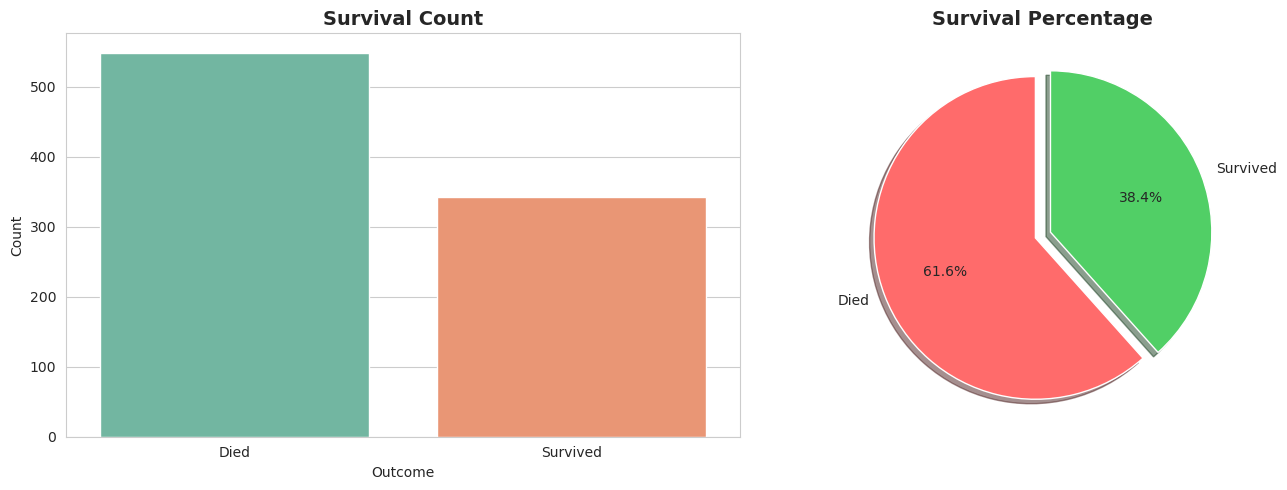

In [7]:
survival_rate = titanic['survived'].mean() * 100
print(f"Overall Survival Rate: {survival_rate:.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=titanic, x='survived', palette='Set2', ax=axes[0])
axes[0].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_xlabel('Outcome')
axes[0].set_ylabel('Count')

survived_counts = titanic['survived'].value_counts()
axes[1].pie(survived_counts, labels=['Died', 'Survived'], autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'], explode=[0.05, 0.05],
            shadow=True, startangle=90)
axes[1].set_title('Survival Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_211/2462105001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='sex', y='survived', palette='Set1', ax=axes[0])
/tmp/ipykernel_211/2462105001.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='pclass', y='survived', palette='Set2', ax=axes[1])


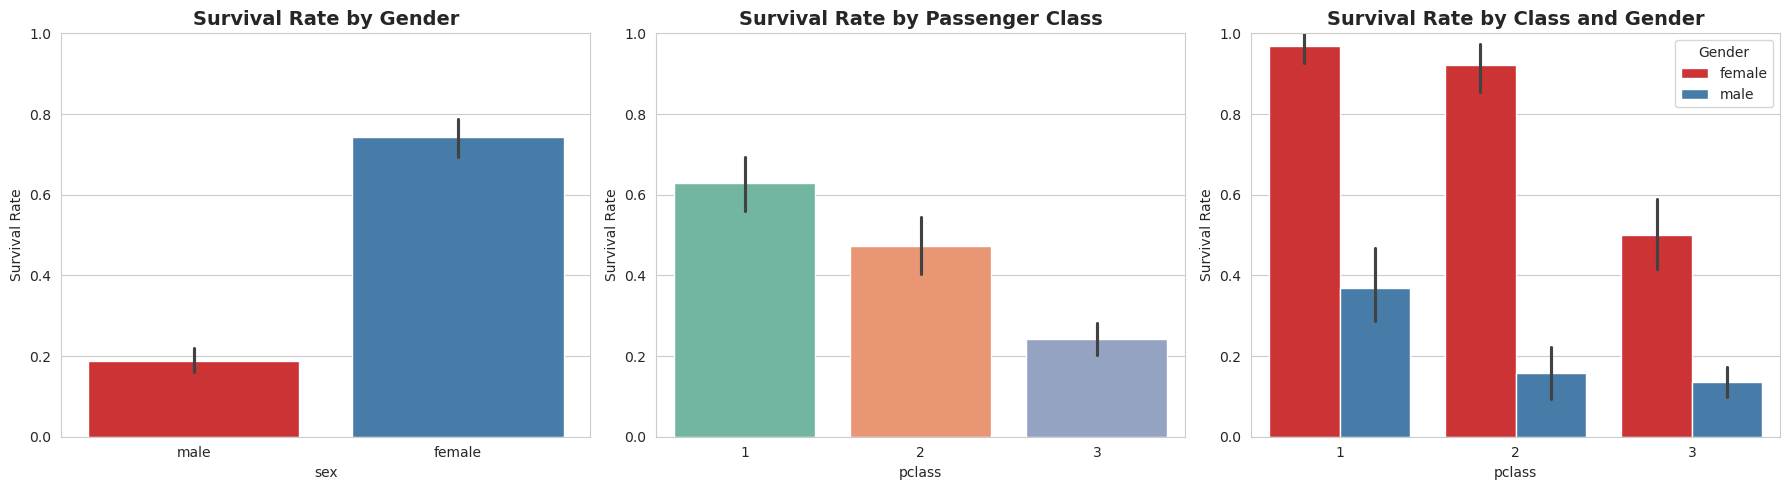

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=titanic, x='sex', y='survived', palette='Set1', ax=axes[0])
axes[0].set_title('Survival Rate by Gender', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Survival Rate')
axes[0].set_ylim(0, 1)

sns.barplot(data=titanic, x='pclass', y='survived', palette='Set2', ax=axes[1])
axes[1].set_title('Survival Rate by Passenger Class', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

sns.barplot(data=titanic, x='pclass', y='survived', hue='sex', palette='Set1', ax=axes[2])
axes[2].set_title('Survival Rate by Class and Gender', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Survival Rate')
axes[2].set_ylim(0, 1)
axes[2].legend(title='Gender')

plt.tight_layout()
plt.show()

In [9]:
print("Survival Rate by Gender:")
print(titanic.groupby('sex')['survived'].mean().round(3))

print("\nSurvival Rate by Class:")
print(titanic.groupby('pclass')['survived'].mean().round(3))

print("\nSurvival Rate by Gender and Class:")
print(titanic.groupby(['sex', 'pclass'])['survived'].mean().round(3))

Survival Rate by Gender:
sex
female    0.742
male      0.189
Name: survived, dtype: float64

Survival Rate by Class:
pclass
1    0.630
2    0.473
3    0.242
Name: survived, dtype: float64

Survival Rate by Gender and Class:
sex     pclass
female  1         0.968
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: survived, dtype: float64


/tmp/ipykernel_211/1089944692.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x='survived', y='age', palette='Set2', ax=axes[1])
/tmp/ipykernel_211/1089944692.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Died', 'Survived'])


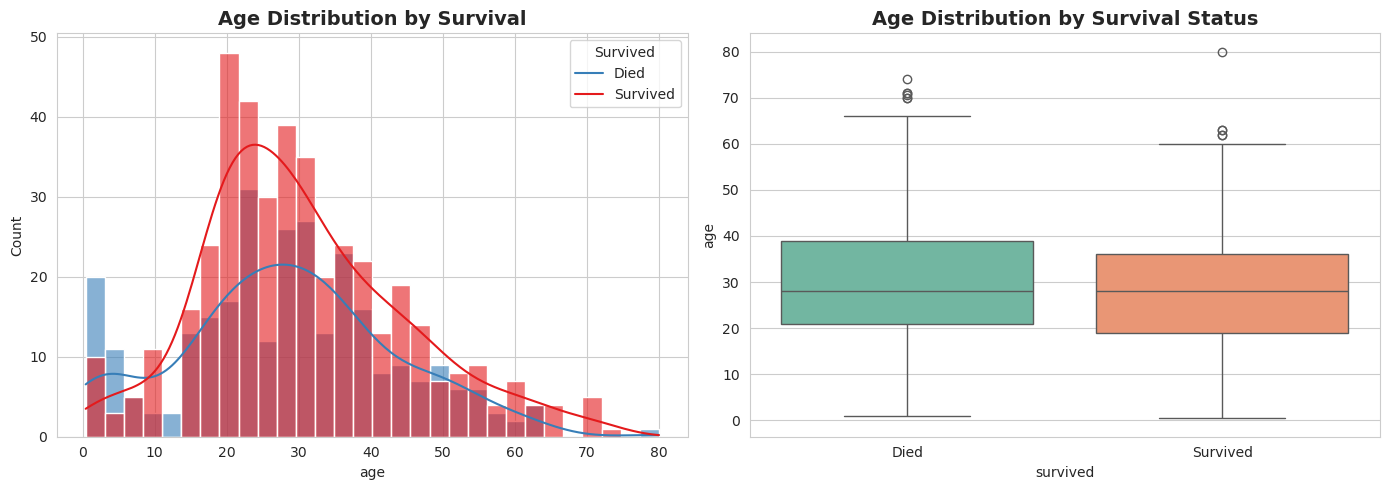

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=titanic, x='age', hue='survived', bins=30, kde=True,
             palette='Set1', alpha=0.6, ax=axes[0])
axes[0].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
axes[0].legend(title='Survived', labels=['Died', 'Survived'])

sns.boxplot(data=titanic, x='survived', y='age', palette='Set2', ax=axes[1])
axes[1].set_title('Age Distribution by Survival Status', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Died', 'Survived'])

plt.tight_layout()
plt.show()

/tmp/ipykernel_211/3600990414.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='age_group', y='survived', palette='viridis')


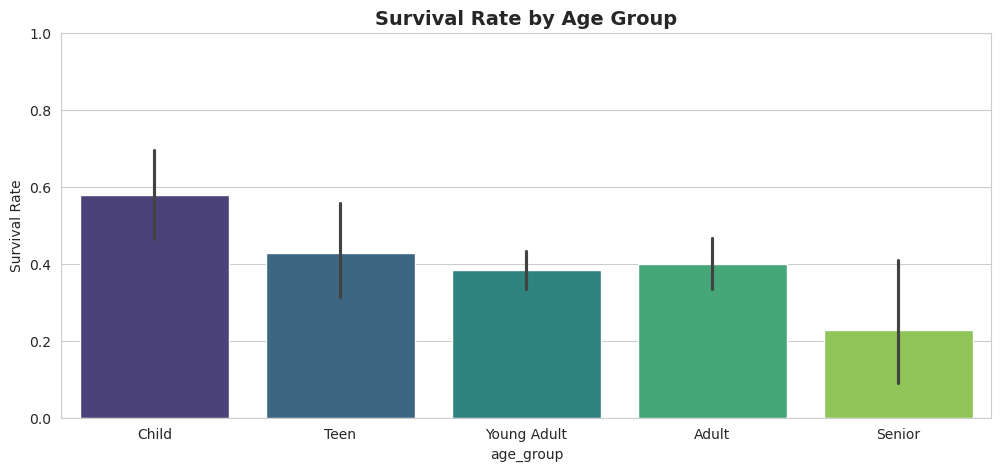

Survival Rate by Age Group:
age_group
Child          0.580
Teen           0.429
Young Adult    0.383
Adult          0.400
Senior         0.227
Name: survived, dtype: float64


In [11]:
titanic['age_group'] = pd.cut(titanic['age'],
                               bins=[0, 12, 18, 35, 60, 100],
                               labels=['Child', 'Teen', 'Young Adult', 'Adult', 'Senior'])

plt.figure(figsize=(12, 5))
sns.barplot(data=titanic, x='age_group', y='survived', palette='viridis')
plt.title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

print("Survival Rate by Age Group:")
print(titanic.groupby('age_group', observed=True)['survived'].mean().round(3))

/tmp/ipykernel_211/1634949338.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x='survived', y='fare', palette='Set1', ax=axes[0])
/tmp/ipykernel_211/1634949338.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Died', 'Survived'])
/tmp/ipykernel_211/1634949338.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=titanic, x='survived', y='fare', palette='Set2', ax=axes[1])
/tmp/ipykernel_211/1634949338.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklab

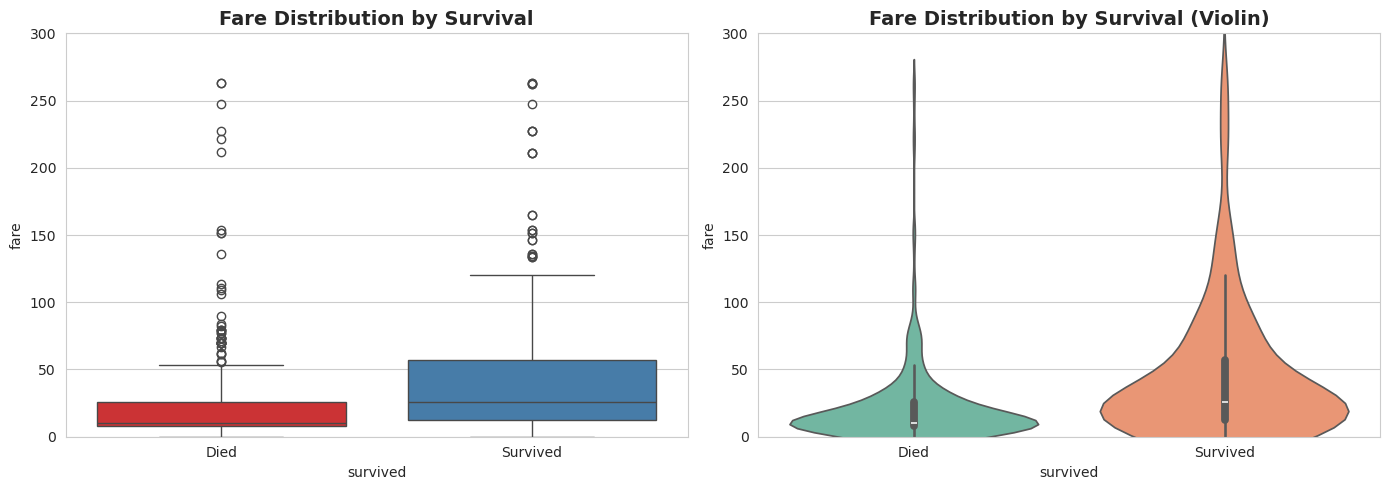

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=titanic, x='survived', y='fare', palette='Set1', ax=axes[0])
axes[0].set_title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Died', 'Survived'])
axes[0].set_ylim(0, 300)

sns.violinplot(data=titanic, x='survived', y='fare', palette='Set2', ax=axes[1])
axes[1].set_title('Fare Distribution by Survival (Violin)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Died', 'Survived'])
axes[1].set_ylim(0, 300)

plt.tight_layout()
plt.show()

/tmp/ipykernel_211/270058262.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='fare_bin', y='survived', palette='coolwarm')


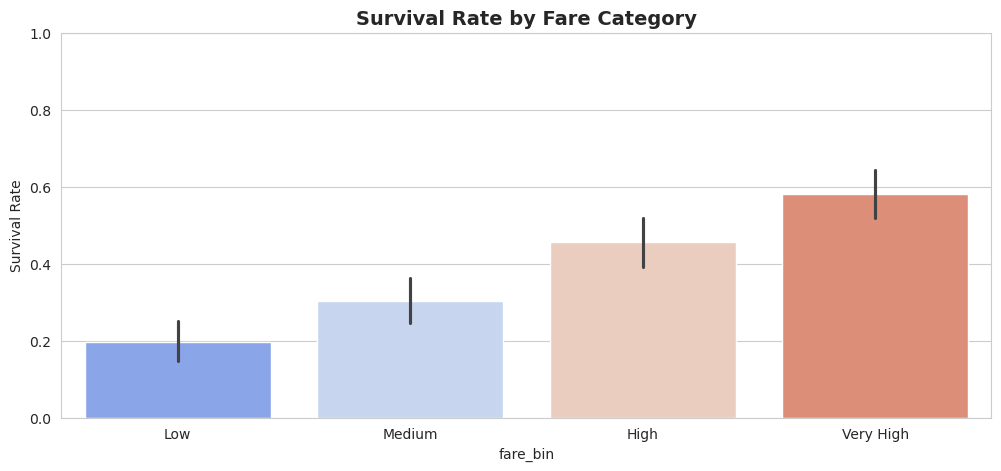

Survival Rate by Fare Category:
fare_bin
Low          0.197
Medium       0.304
High         0.455
Very High    0.581
Name: survived, dtype: float64


In [13]:
titanic['fare_bin'] = pd.qcut(titanic['fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

plt.figure(figsize=(12, 5))
sns.barplot(data=titanic, x='fare_bin', y='survived', palette='coolwarm')
plt.title('Survival Rate by Fare Category', fontsize=14, fontweight='bold')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.show()

print("Survival Rate by Fare Category:")
print(titanic.groupby('fare_bin', observed=True)['survived'].mean().round(3))

/tmp/ipykernel_211/2211649515.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=titanic, x='embarked', y='survived', palette='Set2', ax=axes[1])


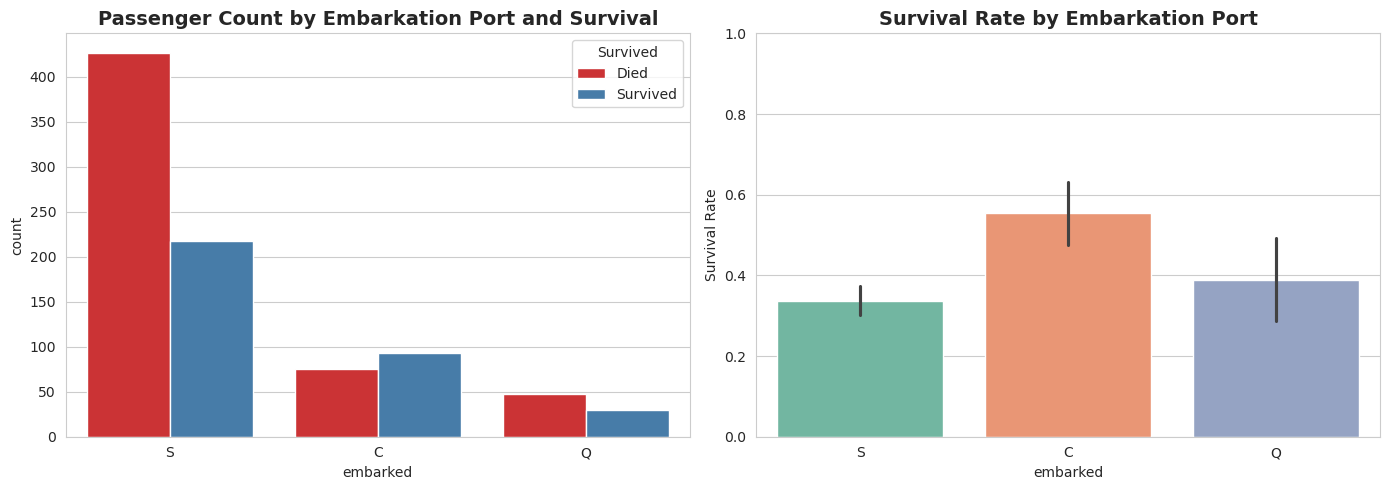

Survival Rate by Embarkation Port:
embarked
C    0.554
Q    0.390
S    0.337
Name: survived, dtype: float64

Passenger Count by Port:
embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=titanic, x='embarked', hue='survived', palette='Set1', ax=axes[0])
axes[0].set_title('Passenger Count by Embarkation Port and Survival', fontsize=14, fontweight='bold')
axes[0].legend(title='Survived', labels=['Died', 'Survived'])

sns.barplot(data=titanic, x='embarked', y='survived', palette='Set2', ax=axes[1])
axes[1].set_title('Survival Rate by Embarkation Port', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Survival Rate by Embarkation Port:")
print(titanic.groupby('embarked')['survived'].mean().round(3))
print("\nPassenger Count by Port:")
print(titanic['embarked'].value_counts())

/tmp/ipykernel_211/2434578297.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=titanic, x='pclass', y='age', palette='Set2', ax=axes[1])


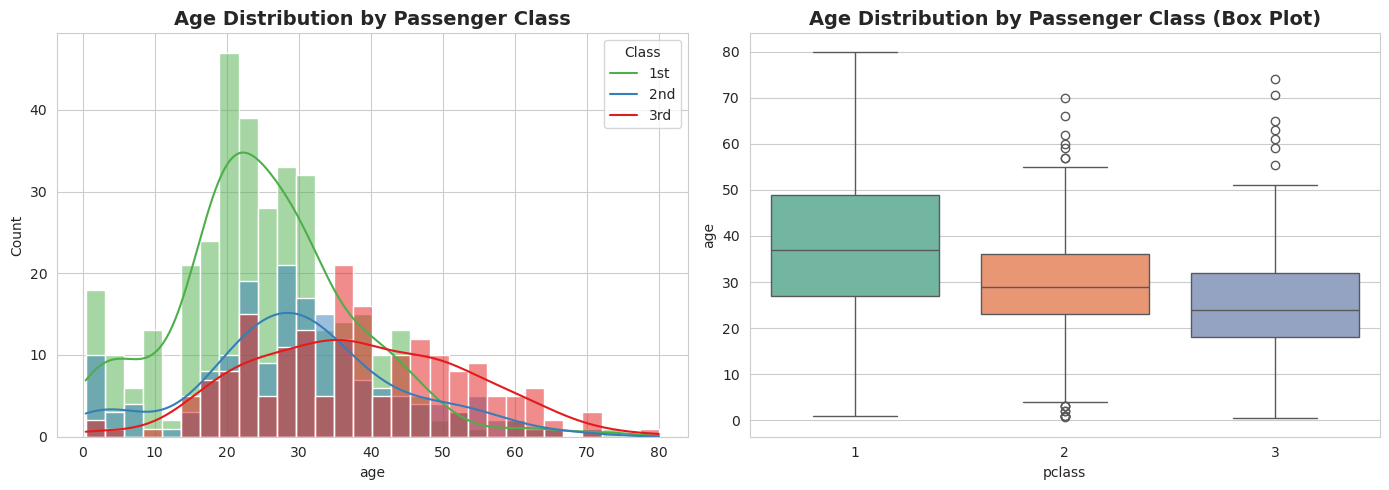

Age Statistics by Passenger Class:
        count   mean   std   min   25%   50%   75%   max
pclass                                                  
1       186.0  38.23  14.8  0.92  27.0  37.0  49.0  80.0
2       173.0  29.88  14.0  0.67  23.0  29.0  36.0  70.0
3       355.0  25.14  12.5  0.42  18.0  24.0  32.0  74.0


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=titanic, x='age', hue='pclass', bins=30, kde=True,
             palette='Set1', alpha=0.5, ax=axes[0])
axes[0].set_title('Age Distribution by Passenger Class', fontsize=14, fontweight='bold')
axes[0].legend(title='Class', labels=['1st', '2nd', '3rd'])

sns.boxplot(data=titanic, x='pclass', y='age', palette='Set2', ax=axes[1])
axes[1].set_title('Age Distribution by Passenger Class (Box Plot)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("Age Statistics by Passenger Class:")
print(titanic.groupby('pclass')['age'].describe().round(2))

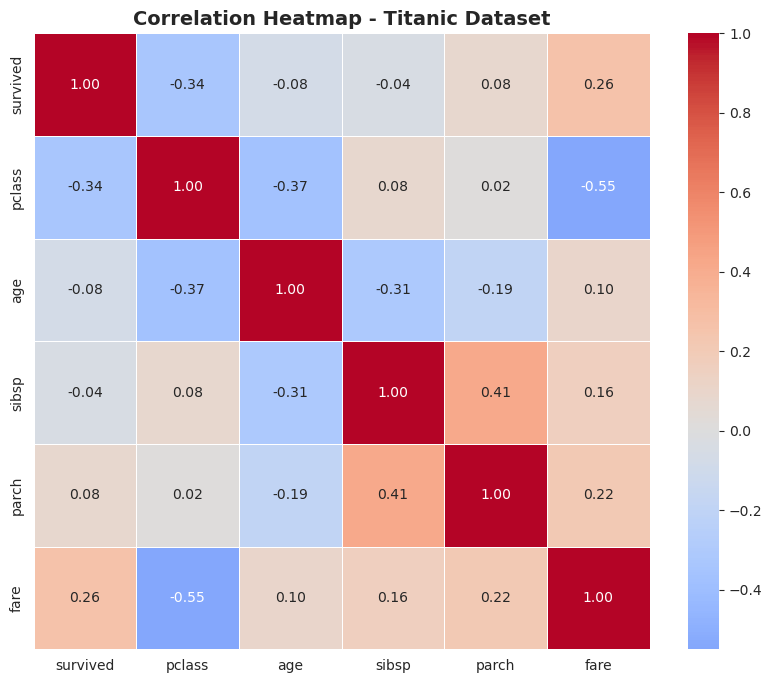

In [16]:
numeric_cols = ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
corr_matrix = titanic[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlation Heatmap - Titanic Dataset', fontsize=14, fontweight='bold')
plt.show()